# Index-Option Backtest — Nearest-ATM Straddle

A compact, **strategy-agnostic** event-driven backtester run over 21 trading days of NSE tick data (Nov 2022) for **NIFTY** and **BANKNIFTY**.

**The engine knows nothing about the strategy.** A strategy observes the market each second and returns orders; the engine fills them, tracks signed positions and cash, marks the book to market, and records everything. Swapping strategies is a one-method change.

```
          observes market                     emits orders
  Strategy  ----------->  MarketSnapshot  ----------------->  BacktestEngine
                                                                   |
                                fills / marks / position cap       v
                                                              Portfolio  -->  per-second MTM curve + trade log
```

**Strategy under test (as specified):** every second, pick the strike nearest the front-month futures (`*-I.csv`), hold 1×CE + 1×PE, and *roll* (sell the pair, buy the new pair) whenever the nearest strike changes. Flat at every close. The brief is explicit that profitability is **not** the objective — this is about measuring a strategy correctly.

In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd

from mft.engine import BacktestResult
from mft import analytics as an

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "font.size": 9, "axes.titlesize": 11})

UNDERLIERS = ["NIFTY", "BANKNIFTY", "FINNIFTY"]

def load_results(out_dir="results"):
    res = {}
    for u in UNDERLIERS:
        mtm = pd.read_parquet(f"{out_dir}/mtm_{u}.parquet")
        trades = pd.read_parquet(f"{out_dir}/trades_{u}.parquet")
        res[u] = BacktestResult(u, mtm, trades, lot_size=1.0)
    return res

# Re-run if results are missing (≈20s); otherwise load the saved run.
try:
    results = load_results()
except FileNotFoundError:
    from mft.run import run_all
    results = run_all(verbose=False)

{u: (len(r.mtm), len(r.trades)) for u, r in results.items()}

{'NIFTY': (472521, 15764),
 'BANKNIFTY': (472521, 17552),
 'FINNIFTY': (472521, 2020)}

## Headline metrics

PnL is in **index points** for a 1-unit position (lot size and costs are configurable knobs on the engine; here both underliers use the spec's frictionless, 1-lot setup). `rolls` counts strike changes × 2 legs; `sharpe_like` annualises daily-PnL mean/std.

In [2]:
summary = pd.DataFrame([an.compute_metrics(r).as_row() for r in results.values()])
combined_final = float(an.combined_equity(results).iloc[-1])
print(f"Combined final PnL: {combined_final:,.1f} points")
summary

Combined final PnL: -2,343.3 points


,underlier,final_pnl,fills,rolls,max_drawdown,sharpe_like,avg_daily_pnl,pnl_std,fees
0,NIFTY,-508.85,15764,7882,-555.60,-11.471,-24.23,33.53,0.0
1,BANKNIFTY,-1477.00,17552,8776,-1536.05,-17.314,-70.33,64.49,0.0
2,FINNIFTY,-357.45,2020,1010,-485.50,-9.238,-17.02,29.25,0.0


## Trust the numbers first: independent reconciliation

The engine builds PnL incrementally through average-cost bookkeeping. Before drawing a single conclusion, we recompute the same PnL two ways that share **no code** with the engine's accounting:

- a one-line **cash-flow identity** over the trade log (flat at the end => PnL is just the negative of every cash flow, less fees), and
- a full **per-second equity curve rebuilt from scratch** from the fills plus the raw price series.

If the engine, both recomputations, and the rebuilt curve all agree to floating-point tolerance, the accounting is correct by construction.

In [3]:
from mft import reconcile
from mft.data import Dataset

dataset = Dataset("allData")
recon = pd.DataFrame([reconcile.reconcile(r, dataset).as_row() for r in results.values()])
assert recon["reconciled"].all(), "Reconciliation failed!"
print("Engine == cash-flow == round-trip == rebuilt curve, for every underlier.")
recon

Engine == cash-flow == round-trip == rebuilt curve, for every underlier.


,underlier,engine_pnl,cashflow_pnl,roundtrip_pnl,curve_max_abs_diff,reconciled
0,NIFTY,-508.85,-508.85,-508.85,1.360000e-12,True
1,BANKNIFTY,-1477.00,-1477.00,-1477.00,2.960000e-12,True
2,FINNIFTY,-357.45,-357.45,-357.45,2.840000e-13,True


## Cumulative mark-to-market and drawdown

The steady downward drift is the signature of a perpetually-long ATM straddle paying theta — a useful sanity check that the engine prices the book correctly across rolls and overnight gaps (dates are chained; weekends/holidays are simply absent).

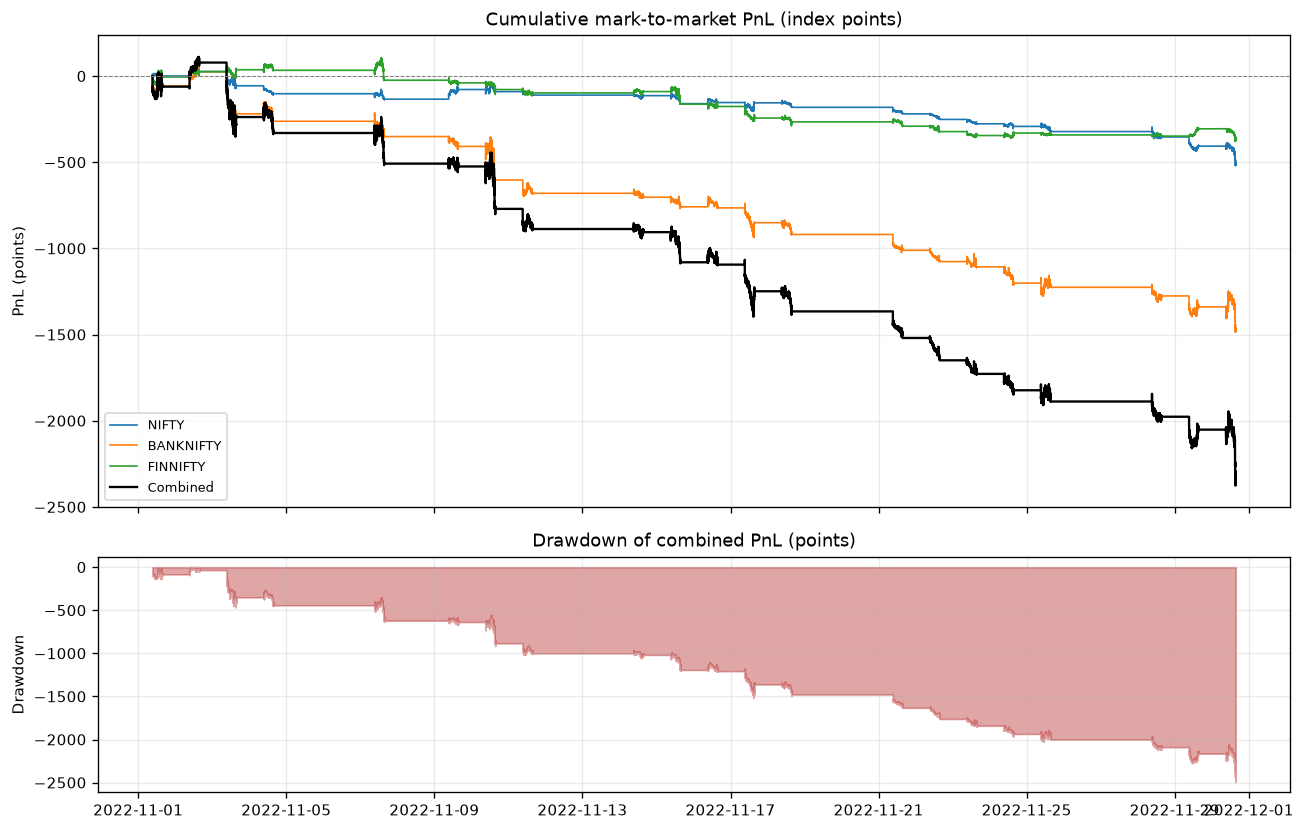

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
an.plot_equity(results, axes[0])
an.plot_drawdown(results, axes[1])
fig.tight_layout()

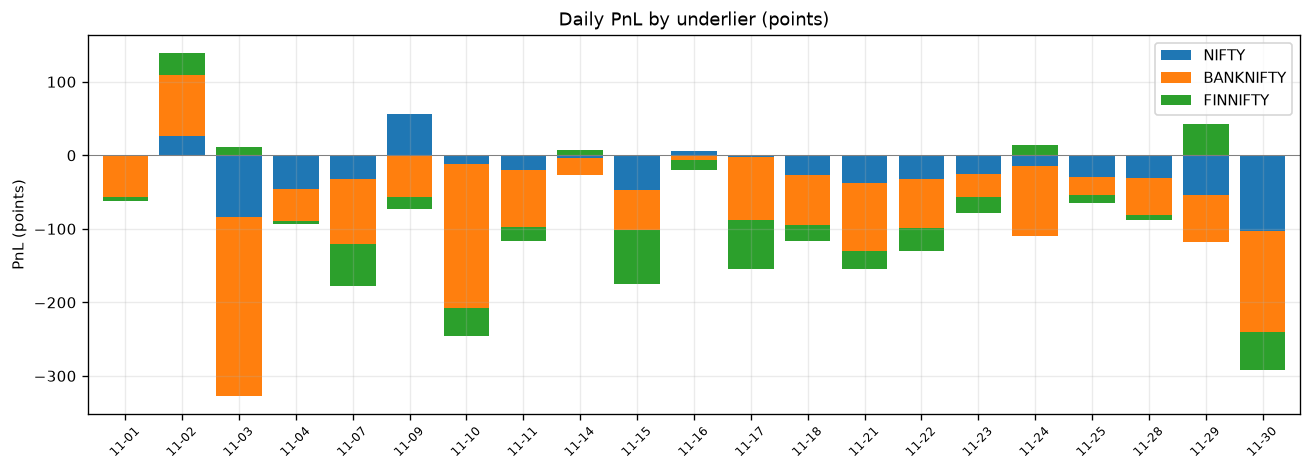

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
an.plot_daily_pnl(results, ax)
fig.tight_layout()

## Position timeline — watching the strike follow the futures

For a single day, the held strike (step line) tracks the futures (smooth line). Every step is a roll: the old straddle is sold and the new one bought.

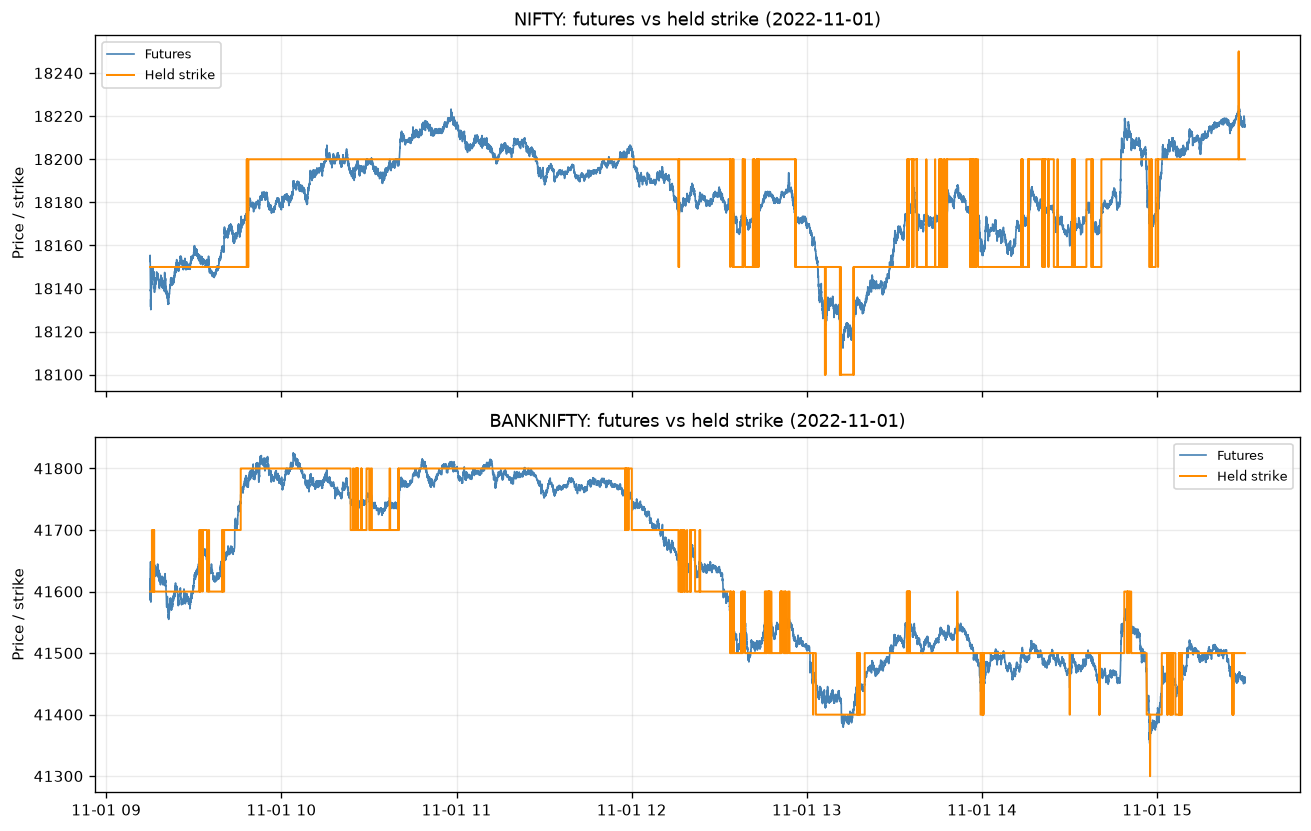

In [6]:
sample_day = results["NIFTY"].mtm.index[0].normalize()
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
an.plot_position_timeline(results["NIFTY"], sample_day, axes[0])
an.plot_position_timeline(results["BANKNIFTY"], sample_day, axes[1])
fig.tight_layout()

## Trade microstructure: how long do we hold, and what does each leg earn?

NIFTY round-trip legs: 7,882
median hold: 3s   mean hold: 120s
win rate (leg pnl > 0): 44.4%


,symbol,strike,opt_type,entry,exit,qty,entry_px,exit_px,pnl,hold_s
0,NIFTY22110318000CE,18000,CE,2022-11-03 09:15:00,2022-11-03 09:15:05,1,65.00,44.75,-20.25,5.0
1,NIFTY22110318000PE,18000,PE,2022-11-03 09:15:00,2022-11-03 09:15:05,1,67.15,65.70,-1.45,5.0
2,NIFTY22110318050CE,18050,CE,2022-11-03 09:15:05,2022-11-03 09:18:31,1,25.75,40.90,15.15,206.0
3,NIFTY22110318050CE,18050,CE,2022-11-03 09:18:53,2022-11-03 09:19:02,1,41.20,41.25,0.05,9.0
4,NIFTY22110318050CE,18050,CE,2022-11-03 09:19:03,2022-11-03 09:19:14,1,41.65,41.55,-0.10,11.0


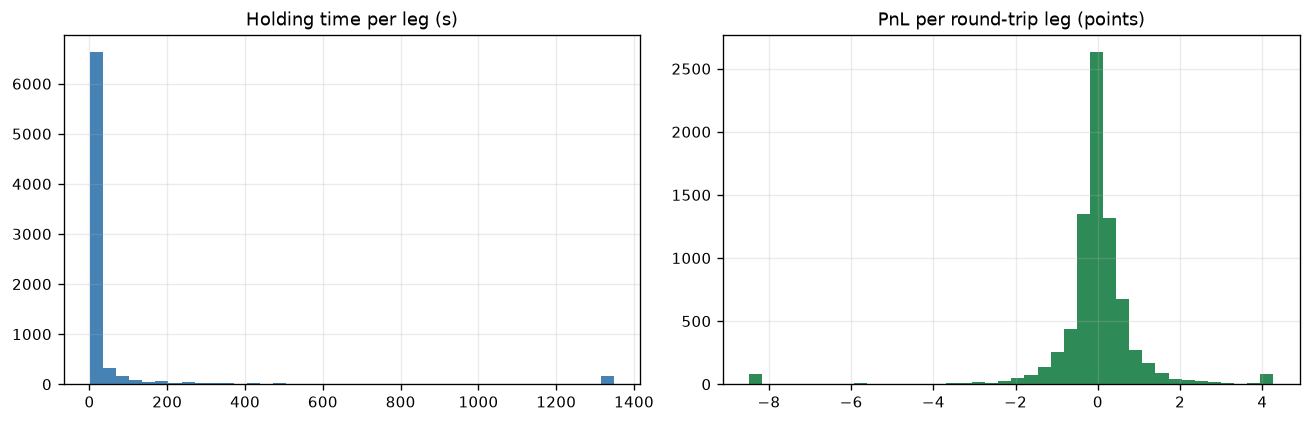

In [7]:
rt = an.round_trips(results["NIFTY"].trades)
print(f"NIFTY round-trip legs: {len(rt):,}")
print(f"median hold: {rt['hold_s'].median():.0f}s   mean hold: {rt['hold_s'].mean():.0f}s")
print(f"win rate (leg pnl > 0): {(rt['pnl'] > 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
rt["hold_s"].clip(upper=rt["hold_s"].quantile(0.98)).hist(bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Holding time per leg (s)")
rt["pnl"].clip(*rt["pnl"].quantile([0.01, 0.99])).hist(bins=40, ax=axes[1], color="seagreen")
axes[1].set_title("PnL per round-trip leg (points)")
fig.tight_layout()
rt.head()

## Why does it lose? PnL attribution (no Greeks required)

The headline loss is not noise — it is structural, and we can prove what it is. Each leg's PnL decomposes **exactly** into two pieces:

- **Directional**: the change in the legs' *intrinsic* value (`|F - K|`) as the futures moves — what the move was actually worth.
- **Time / volatility (extrinsic)**: everything left over — the decay of the options' time value. A perpetually-long ATM straddle is structurally short theta, so this term bleeds.

Summed across every leg, `directional + extrinsic` reconstructs realised PnL to the point, so this is an identity rather than a model. The chart below shows the move *did* make money on intrinsic value — it was simply overwhelmed by time decay.

,underlier,directional_pnl,extrinsic_pnl,fees,total_pnl
0,NIFTY,5926.85,-6435.70,0.0,-508.85
1,BANKNIFTY,19772.20,-21249.20,0.0,-1477.00
2,FINNIFTY,7997.00,-8354.45,0.0,-357.45


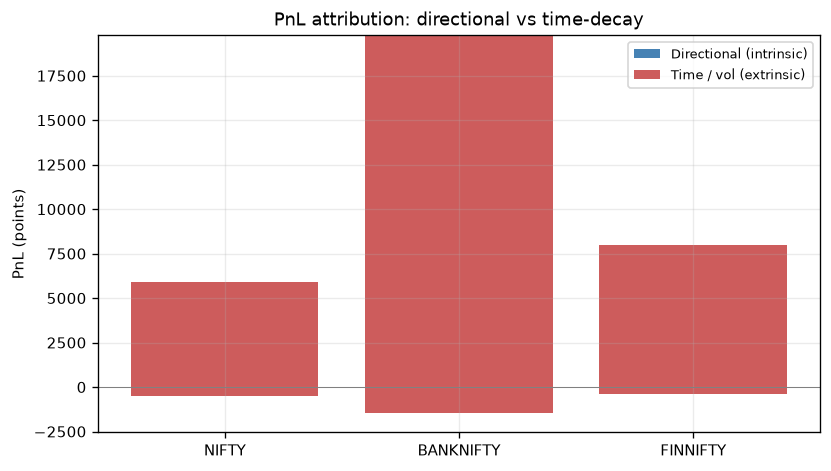

In [8]:
from mft import attribution

atts = [attribution.attribute(r, dataset)[0] for r in results.values()]
attr_table = pd.DataFrame([a.as_row() for a in atts])

fig, ax = plt.subplots(figsize=(7, 4))
attribution.plot_attribution(atts, ax)
fig.tight_layout()
attr_table

## Flexibility: plug in a different strategy in ~10 lines

Because the engine only consumes `Order`s, a completely different idea needs nothing but a new `on_step`. Below, a long-call-only "directional" variant reuses the exact same engine, data layer, portfolio and analytics.

In [9]:
import numpy as np
from mft.core import Order, Side
from mft.data import Dataset
from mft.engine import BacktestEngine
from mft.strategy import Strategy

class NearestCallOnly(Strategy):
    """Hold only the nearest-strike call; roll on strike change."""
    def on_day_start(self, market):
        self.held = None
    def on_step(self, snap, portfolio):
        m = snap.market
        target = m.nearest_strike(m.futures_price)
        if target is None or target == self.held:
            return []
        if not np.isfinite(m.option_price(target, "CE")):
            return []
        orders = []
        if self.held is not None:
            orders.append(Order(m.symbol(self.held, "CE"), Side.SELL, reason="roll_out"))
        orders.append(Order(m.symbol(target, "CE"), Side.BUY, reason="roll_in"))
        self.held = target
        return orders

ds = Dataset("allData")
demo = BacktestEngine(ds).run(NearestCallOnly(), "NIFTY", dates=ds.dates[:3])
an.compute_metrics(demo).as_row()

{'underlier': 'NIFTY',
 'final_pnl': -14.1,
 'fills': 1454,
 'rolls': 727,
 'max_drawdown': -62.8,
 'sharpe_like': -3.402,
 'avg_daily_pnl': -4.7,
 'pnl_std': 21.93,
 'fees': 0.0}

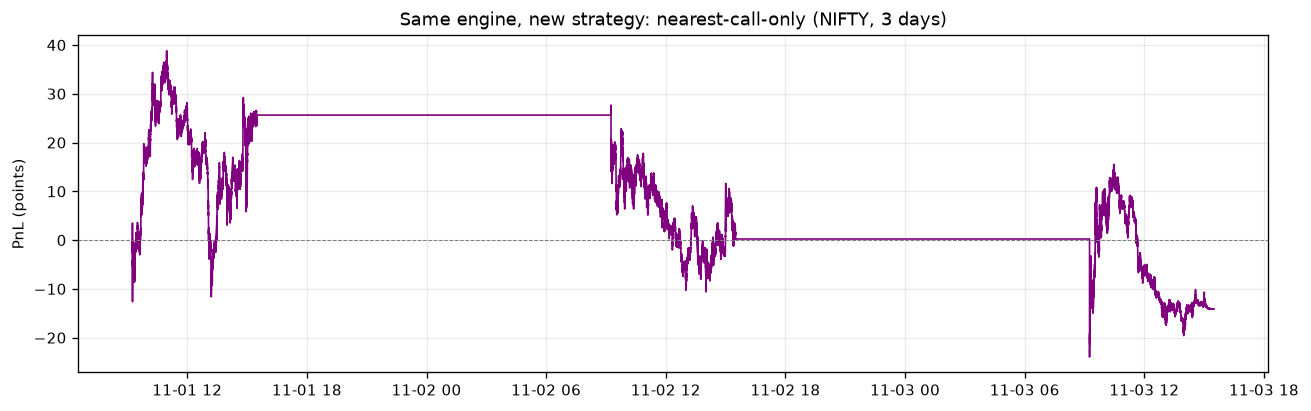

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(demo.mtm.index, demo.mtm["equity"], color="purple", lw=1.0)
ax.axhline(0, color="grey", lw=0.6, ls="--")
ax.set_title("Same engine, new strategy: nearest-call-only (NIFTY, 3 days)")
ax.set_ylabel("PnL (points)")
fig.tight_layout()